<a href="https://colab.research.google.com/github/mileygg/Chronic-Disease/blob/main/Statistical_Testing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd


In [2]:
url = 'https://raw.githubusercontent.com/mileygg/Chronic-Disease/refs/heads/main/chronic_disease_data.csv'

df = pd.read_csv(url)

df.head()

,year,state_code,state_name,health_topic,indicator_metric,measurement_type,numeric_value,demographic_group
0,2019,AL,Alabama,Tobacco,Quit attempts in the past year among adult cur...,Crude Prevalence,NaN,"Hawaiian or Pacific Islander, non-Hispanic"
1,2019,CT,Connecticut,Cardiovascular Disease,High cholesterol among adults who have been sc...,Crude Prevalence,30.0,Hispanic
2,2019,DE,Delaware,Cardiovascular Disease,High blood pressure among adults,Crude Prevalence,38.8,"White, non-Hispanic"
3,2019,DE,Delaware,Cardiovascular Disease,Diseases of the heart mortality among all peop...,Number,2053.0,Overall
4,2019,DE,Delaware,Diabetes,Gestational diabetes among women with a recent...,Crude Prevalence,12.5,"White, non-Hispanic"


In [3]:
# Dimensions (rows, columns)
df.shape

# Column names
df.columns

# Data types and missing values
df.info()

# Summary statistics
df.describe()

# Summary including categorical variables
df.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43985 entries, 0 to 43984
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   year               43985 non-null  int64  
 1   state_code         43985 non-null  object 
 2   state_name         43985 non-null  object 
 3   health_topic       43985 non-null  object 
 4   indicator_metric   43985 non-null  object 
 5   measurement_type   43985 non-null  object 
 6   numeric_value      25875 non-null  float64
 7   demographic_group  43985 non-null  object 
dtypes: float64(1), int64(1), object(6)
memory usage: 2.7+ MB


,year,state_code,state_name,health_topic,indicator_metric,measurement_type,numeric_value,demographic_group
count,43985.000000,43985,43985,43985,43985,43985,25875.000000,43985
unique,NaN,55,55,3,19,6,NaN,9
top,NaN,AL,Alabama,Cardiovascular Disease,Coronary heart disease mortality among all peo...,Crude Prevalence,NaN,Overall
freq,NaN,833,833,21080,3744,13492,NaN,5833
mean,2020.118131,NaN,NaN,NaN,NaN,NaN,1105.447734,NaN
std,0.962041,NaN,NaN,NaN,NaN,NaN,15819.041819,NaN
min,2019.000000,NaN,NaN,NaN,NaN,NaN,0.000000,NaN
25%,2019.000000,NaN,NaN,NaN,NaN,NaN,17.100000,NaN
50%,2020.000000,NaN,NaN,NaN,NaN,NaN,35.700000,NaN
75%,2021.000000,NaN,NaN,NaN,NaN,NaN,82.500000,NaN


In [4]:

# Check missing values
df.isnull().sum()

# Check for duplicate rows
df.duplicated().sum()

# Remove duplicates
df = df.drop_duplicates()

# Remove extra whitespace from text columns
text_cols = df.select_dtypes(include='object').columns

for col in text_cols:
    df[col] = df[col].str.strip()

# Verify no duplicate rows remain
print(df.duplicated().sum())

0


In [5]:
# Check for inconsistent categories
for col in text_cols:
    print(f"{col}: {df[col].nunique()} unique values")

state_code: 55 unique values
state_name: 55 unique values
health_topic: 3 unique values
indicator_metric: 19 unique values
measurement_type: 6 unique values
demographic_group: 9 unique values


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [7]:
print("Rows and columns:", df.shape)
print("\nYears:", sorted(df["year"].unique()))
print("\nNumber of states and territories:", df["state_name"].nunique())
print("Number of health topics:", df["health_topic"].nunique())
print("Number of disease indicators:", df["indicator_metric"].nunique())
print("Number of measurement types:", df["measurement_type"].nunique())
print("Number of demographic groups:", df["demographic_group"].nunique())

Rows and columns: (43985, 8)

Years: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022)]

Number of states and territories: 55
Number of health topics: 3
Number of disease indicators: 19
Number of measurement types: 6
Number of demographic groups: 9


In [8]:
print("Health topics:")
print(df["health_topic"].value_counts())

print("\nMeasurement types:")
print(df["measurement_type"].value_counts())

print("\nDemographic groups:")
print(df["demographic_group"].value_counts())

Health topics:
health_topic
Cardiovascular Disease    21080
Diabetes                  12034
Tobacco                   10871
Name: count, dtype: int64

Measurement types:
measurement_type
Crude Prevalence           13492
Age-adjusted Prevalence     8800
Number                      7176
Age-adjusted Rate           7176
Crude Rate                  7176
Proportion                   165
Name: count, dtype: int64

Demographic groups:
demographic_group
Overall                                           5833
American Indian or Alaska Native, non-Hispanic    5584
Hispanic                                          5584
White, non-Hispanic                               5584
Black, non-Hispanic                               5584
Hawaiian or Pacific Islander, non-Hispanic        5116
Asian, non-Hispanic                               5116
Multiracial, non-Hispanic                         5116
Asian or Pacific Islander, non-Hispanic            468
Name: count, dtype: int64


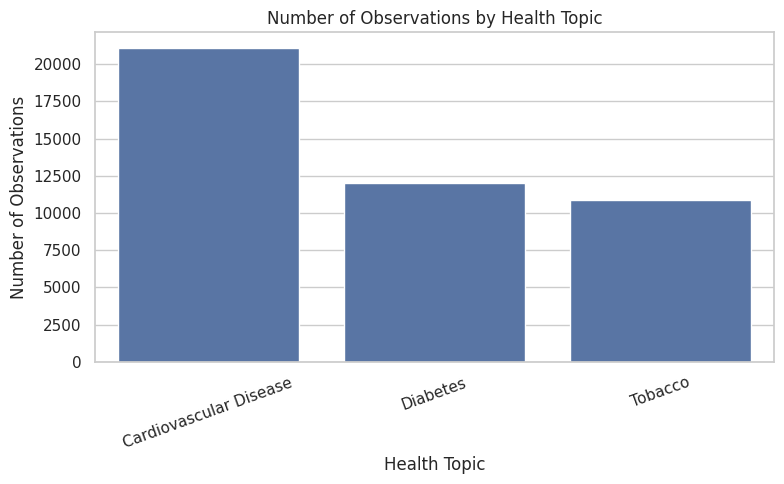

In [9]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="health_topic",
    order=df["health_topic"].value_counts().index
)

plt.title("Number of Observations by Health Topic")
plt.xlabel("Health Topic")
plt.ylabel("Number of Observations")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

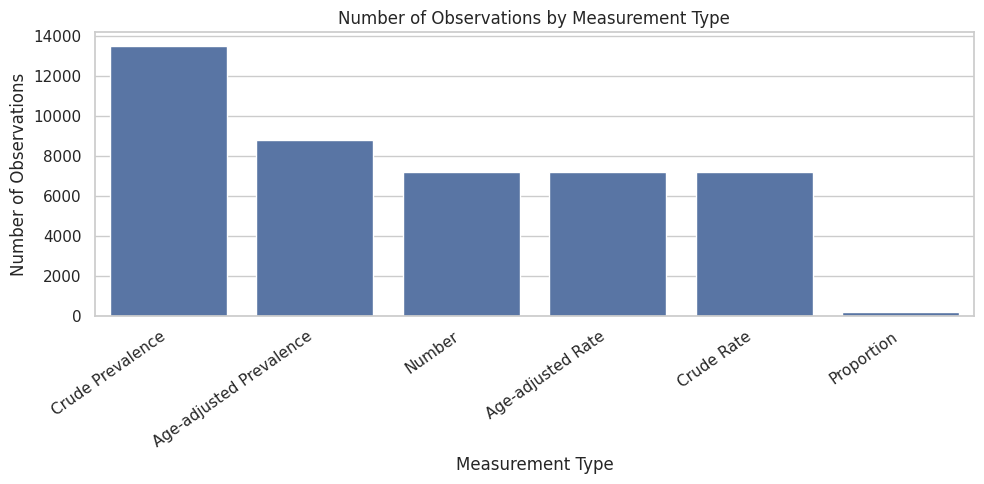

In [10]:
plt.figure(figsize=(10, 5))

measurement_counts = df["measurement_type"].value_counts()

sns.barplot(
    x=measurement_counts.index,
    y=measurement_counts.values
)

plt.title("Number of Observations by Measurement Type")
plt.xlabel("Measurement Type")
plt.ylabel("Number of Observations")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

In [11]:
missing_by_measurement = (
    df.groupby("measurement_type")["numeric_value"]
      .apply(lambda x: x.isna().mean() * 100)
      .sort_values(ascending=False)
)

print(missing_by_measurement)

measurement_type
Crude Prevalence           43.944560
Age-adjusted Prevalence    43.761364
Age-adjusted Rate          38.684504
Crude Rate                 38.684504
Number                     38.684504
Proportion                  1.212121
Name: numeric_value, dtype: float64


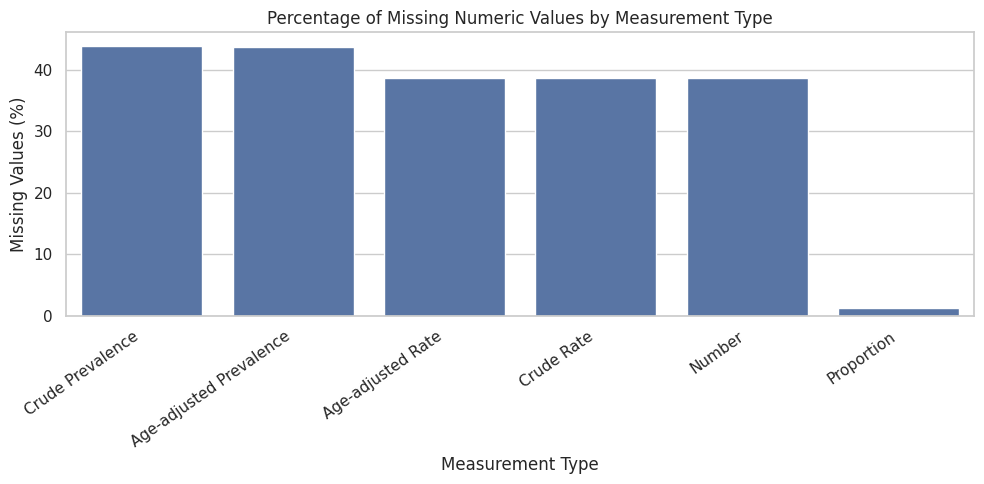

In [12]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x=missing_by_measurement.index,
    y=missing_by_measurement.values
)

plt.title("Percentage of Missing Numeric Values by Measurement Type")
plt.xlabel("Measurement Type")
plt.ylabel("Missing Values (%)")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

In [13]:
missing_by_topic = (
    df.groupby("health_topic")["numeric_value"]
      .apply(lambda x: x.isna().mean() * 100)
      .sort_values(ascending=False)
)

print(missing_by_topic)

health_topic
Tobacco                   49.231901
Diabetes                  47.158052
Cardiovascular Disease    33.600569
Name: numeric_value, dtype: float64


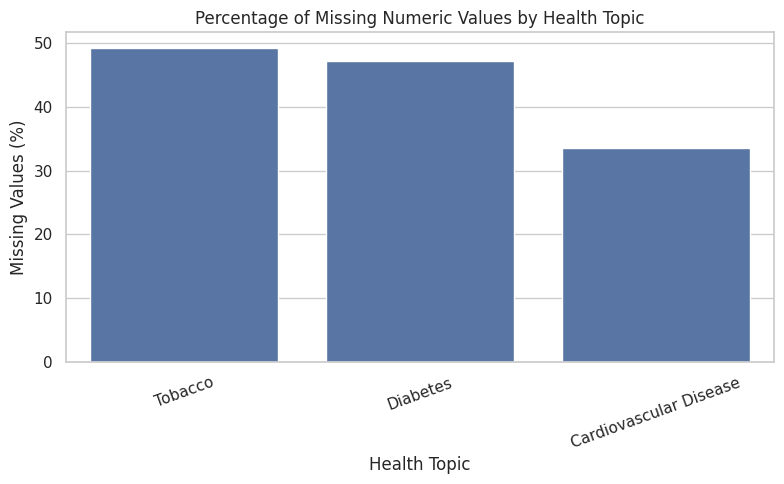

In [14]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=missing_by_topic.index,
    y=missing_by_topic.values
)

plt.title("Percentage of Missing Numeric Values by Health Topic")
plt.xlabel("Health Topic")
plt.ylabel("Missing Values (%)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

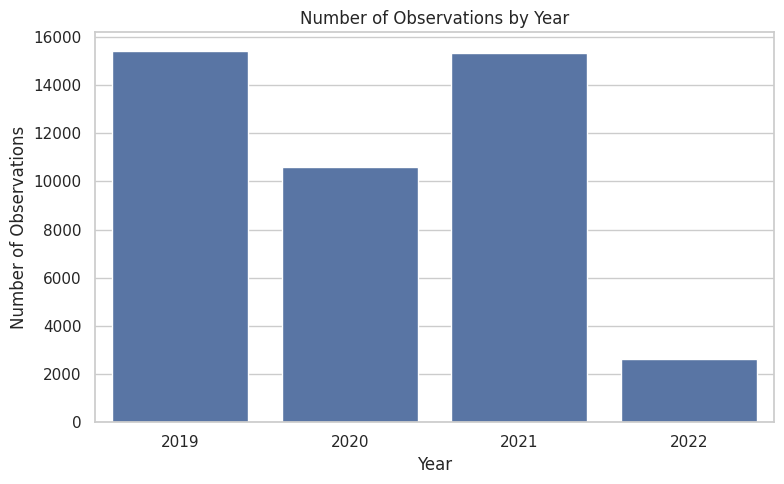

In [15]:
year_counts = df["year"].value_counts().sort_index()

plt.figure(figsize=(8, 5))

sns.barplot(
    x=year_counts.index,
    y=year_counts.values
)

plt.title("Number of Observations by Year")
plt.xlabel("Year")
plt.ylabel("Number of Observations")
plt.tight_layout()
plt.show()

/tmp/ipykernel_421/1262431936.py:13: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


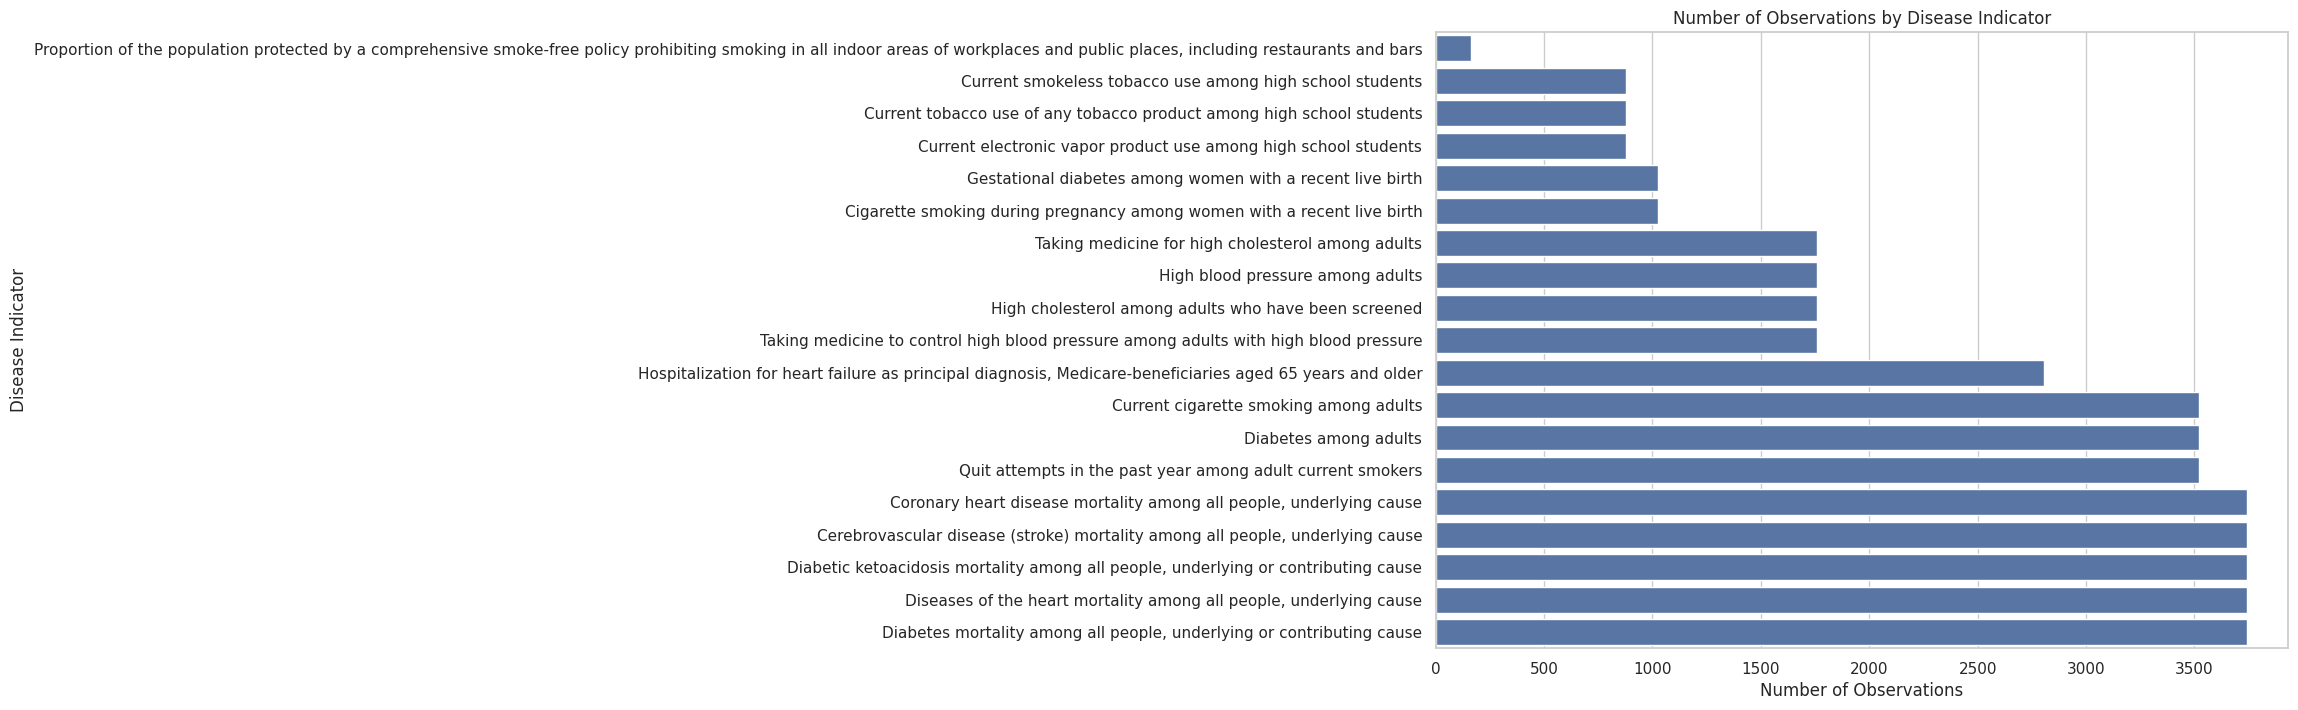

In [16]:
indicator_counts = df["indicator_metric"].value_counts().sort_values()

plt.figure(figsize=(11, 8))

sns.barplot(
    x=indicator_counts.values,
    y=indicator_counts.index
)

plt.title("Number of Observations by Disease Indicator")
plt.xlabel("Number of Observations")
plt.ylabel("Disease Indicator")
plt.tight_layout()
plt.show()

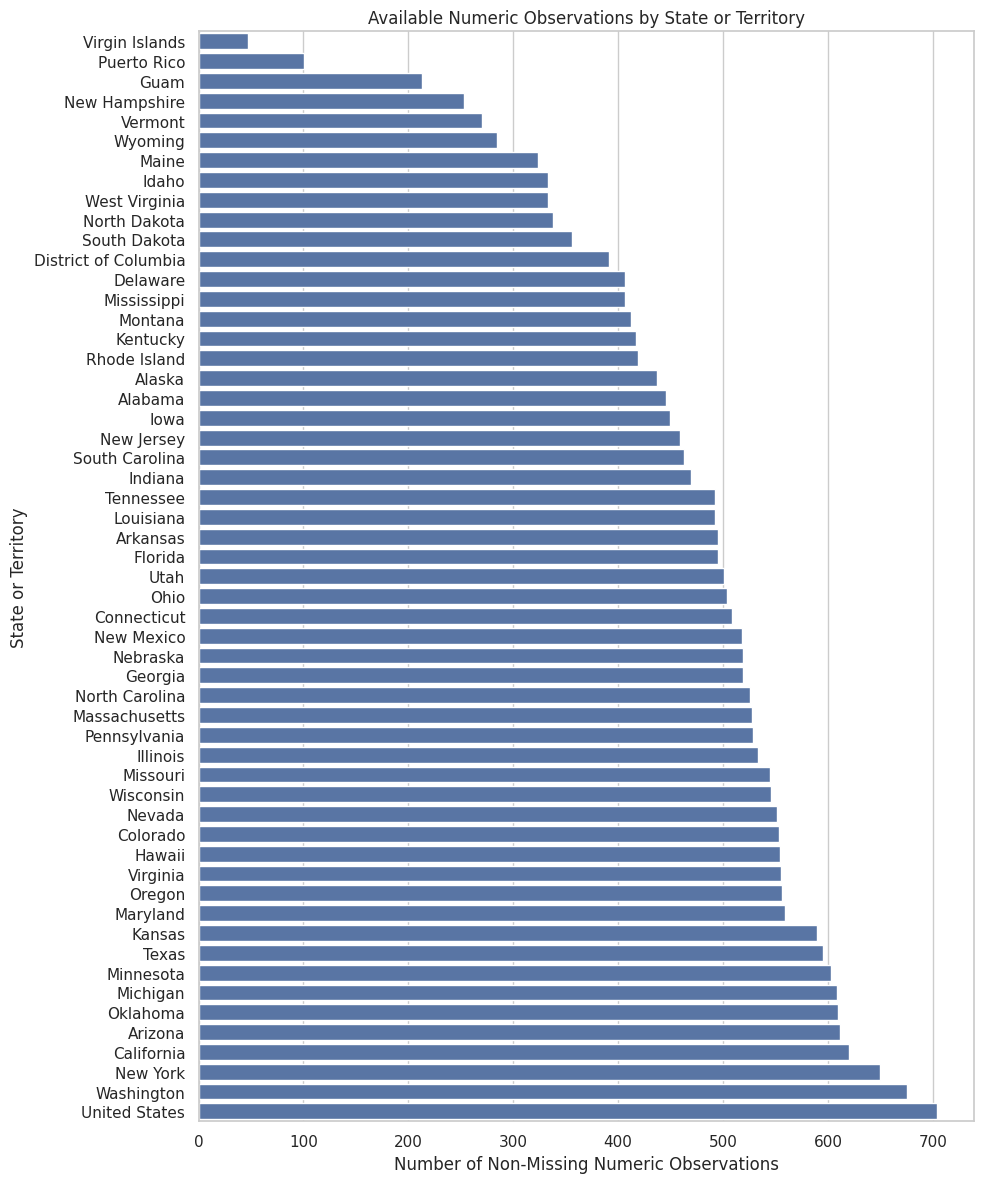

In [17]:
state_coverage = (
    df.groupby("state_name")["numeric_value"]
      .count()
      .sort_values()
)

plt.figure(figsize=(10, 12))

sns.barplot(
    x=state_coverage.values,
    y=state_coverage.index
)

plt.title("Available Numeric Observations by State or Territory")
plt.xlabel("Number of Non-Missing Numeric Observations")
plt.ylabel("State or Territory")
plt.tight_layout()
plt.show()

In [18]:
overall_df = df[df["demographic_group"] == "Overall"].copy()

print("Overall-population dataset shape:", overall_df.shape)
print("\nMissing numeric values:")
print(overall_df["numeric_value"].isna().sum())
print("\nAvailable values:")
print(overall_df["numeric_value"].notna().sum())

Overall-population dataset shape: (5833, 8)

Missing numeric values:
398

Available values:
5435


/tmp/ipykernel_421/1319977335.py:17: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


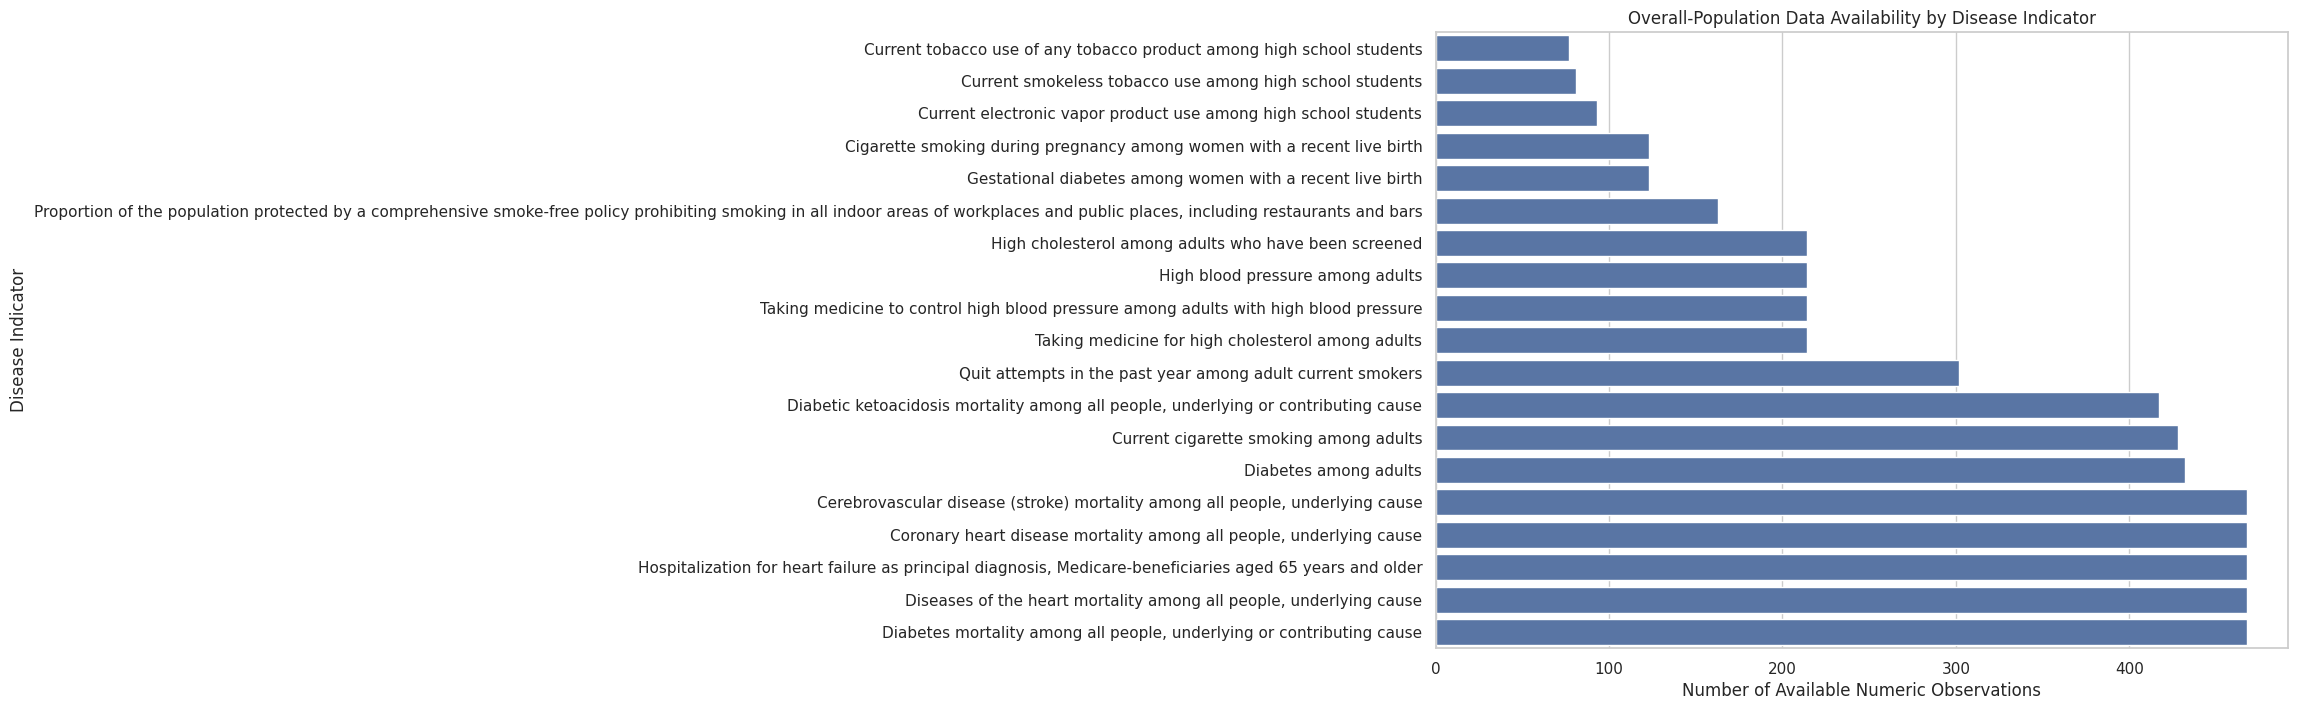

In [19]:
overall_indicator_coverage = (
    overall_df.groupby("indicator_metric")["numeric_value"]
              .count()
              .sort_values()
)

plt.figure(figsize=(11, 8))

sns.barplot(
    x=overall_indicator_coverage.values,
    y=overall_indicator_coverage.index
)

plt.title("Overall-Population Data Availability by Disease Indicator")
plt.xlabel("Number of Available Numeric Observations")
plt.ylabel("Disease Indicator")
plt.tight_layout()
plt.show()

NameError: name 'eda_plot_df' is not defined

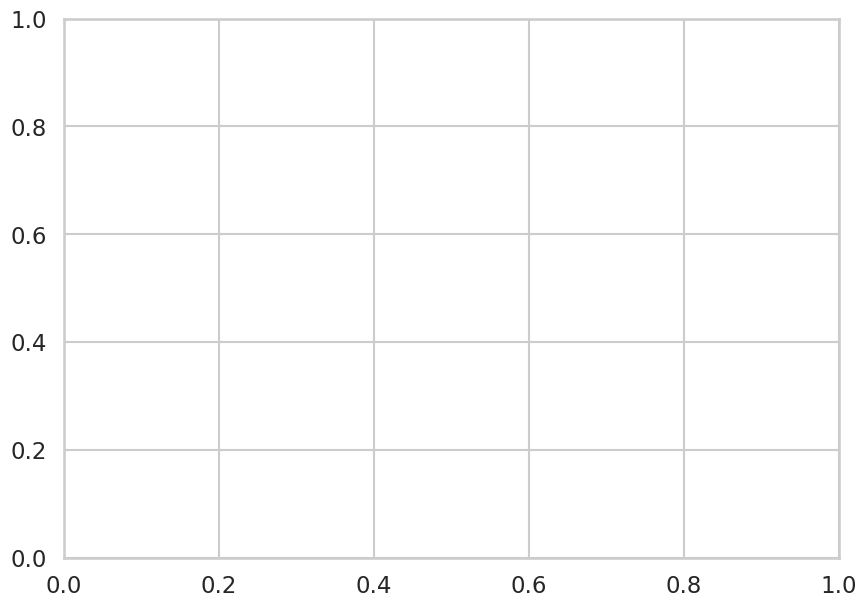

In [20]:
sns.set_theme(style="whitegrid", context="talk")

fig, ax = plt.subplots(figsize=(10, 7))

sns.regplot(
    data=eda_plot_df,
    x=smoking,
    y=diabetes,
    scatter_kws={
        "s": 85,
        "alpha": 0.8,
        "edgecolors": "white"
    },
    line_kws={
        "linewidth": 2
    },
    ci=95,
    ax=ax
)


for _, row in eda_plot_df[
    eda_plot_df["state_code"].isin(states_to_label)
].iterrows():
    ax.annotate(
        row["state_code"],
        (row[smoking], row[diabetes]),
        xytext=(6, 5),
        textcoords="offset points",
        fontsize=10,
        fontweight="bold"
    )

ax.set_title(
    "Adult Smoking and Diabetes Burden Vary Together Across States",
    fontsize=18,
    fontweight="bold",
    pad=16
)

ax.text(
    0.01,
    1.01,
    f"2021 age-adjusted prevalence; Pearson r = {correlation:.2f}",
    transform=ax.transAxes,
    fontsize=11
)

ax.set_xlabel("Current cigarette smoking among adults (%)")
ax.set_ylabel("Diabetes among adults (%)")

sns.despine()
plt.tight_layout()
plt.show()

## Exploratory Data Analysis

Exploratory data analysis was conducted to examine the dataset's structure, coverage, missingness, and distribution across health topics, indicators, years, states, measurement types, and demographic groups. Because the numeric values represent several different units, including prevalence, mortality rates, counts, and proportions, values from different measurement types were not directly averaged or compared. State and indicator coverage were examined to determine which variables could be used reliably in the clustering analysis.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pearsonr
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.feature_selection import f_classif

sns.set_theme(style="whitegrid")

In [ ]:
excluded_codes = ["US", "PR", "GU", "VI"]

analysis_df = df[
    (df["year"] == 2021) &
    (df["demographic_group"] == "Overall") &
    (~df["state_code"].isin(excluded_codes))
].copy()

print("Analysis dataset shape:", analysis_df.shape)
print("Number of states:", analysis_df["state_code"].nunique())
print("Missing numeric values:", analysis_df["numeric_value"].isna().sum())

In [ ]:
smoking = "Current cigarette smoking among adults"
diabetes = "Diabetes among adults"
blood_pressure = "High blood pressure among adults"

hypothesis_indicators = [
    smoking,
    diabetes,
    blood_pressure
]

hypothesis_df = analysis_df[
    (analysis_df["measurement_type"] == "Age-adjusted Prevalence") &
    (analysis_df["indicator_metric"].isin(hypothesis_indicators))
].copy()

hypothesis_wide = hypothesis_df.pivot_table(
    index=["state_code", "state_name"],
    columns="indicator_metric",
    values="numeric_value",
    aggfunc="mean"
).reset_index()

print(hypothesis_wide.shape)
hypothesis_wide.head()

In [ ]:
test1_df = hypothesis_wide[[smoking, diabetes]].dropna()

r1, p1 = pearsonr(
    test1_df[smoking],
    test1_df[diabetes]
)

print("Hypothesis Test #1")
print(f"Number of states: {len(test1_df)}")
print(f"Pearson correlation: {r1:.3f}")
print(f"P-value: {p1:.5f}")

if p1 < 0.05:
    print("Result: Reject the null hypothesis.")
    print("There is a statistically significant relationship between smoking and diabetes.")
else:
    print("Result: Fail to reject the null hypothesis.")
    print("There is not enough evidence of a statistically significant relationship.")

In [ ]:
test2_df = hypothesis_wide[[blood_pressure, diabetes]].dropna()

r2, p2 = pearsonr(
    test2_df[blood_pressure],
    test2_df[diabetes]
)

print("Hypothesis Test #2")
print(f"Number of states: {len(test2_df)}")
print(f"Pearson correlation: {r2:.3f}")
print(f"P-value: {p2:.5f}")

if p2 < 0.05:
    print("Result: Reject the null hypothesis.")
    print("There is a statistically significant relationship between high blood pressure and diabetes.")
else:
    print("Result: Fail to reject the null hypothesis.")
    print("There is not enough evidence of a statistically significant relationship.")

In [ ]:
correlation_matrix = hypothesis_wide[
    [smoking, diabetes, blood_pressure]
].corr()

correlation_matrix.round(2)

In [ ]:
clustering_df = analysis_df[
    analysis_df["measurement_type"].isin([
        "Age-adjusted Prevalence",
        "Age-adjusted Rate"
    ])
].copy()

# Create a unique name that includes both the indicator and measurement type
clustering_df["feature"] = (
    clustering_df["indicator_metric"] +
    " [" +
    clustering_df["measurement_type"] +
    "]"
)

print("Available clustering features:")
print(clustering_df["feature"].value_counts())

In [ ]:
state_matrix = clustering_df.pivot_table(
    index=["state_code", "state_name"],
    columns="feature",
    values="numeric_value",
    aggfunc="mean"
)

print("Original state matrix shape:", state_matrix.shape)
state_matrix.head()

In [ ]:
feature_missingness = (
    state_matrix.isna().mean() * 100
).sort_values(ascending=False)

print(feature_missingness)

In [ ]:
missing_threshold = 20

features_to_keep = feature_missingness[
    feature_missingness <= missing_threshold
].index

state_matrix_reduced = state_matrix[features_to_keep].copy()

print("Features before filtering:", state_matrix.shape[1])
print("Features after filtering:", state_matrix_reduced.shape[1])
print("States:", state_matrix_reduced.shape[0])

In [ ]:
state_matrix_imputed = state_matrix_reduced.apply(
    lambda column: column.fillna(column.median())
)

print(
    "Remaining missing values:",
    state_matrix_imputed.isna().sum().sum()
)

In [ ]:
feature_variance = state_matrix_imputed.var()

zero_variance_features = feature_variance[
    feature_variance == 0
].index.tolist()

print("Zero-variance features:", zero_variance_features)

state_matrix_imputed = state_matrix_imputed.drop(
    columns=zero_variance_features
)

print("Final number of clustering features:", state_matrix_imputed.shape[1])

In [ ]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(state_matrix_imputed)

X_scaled_df = pd.DataFrame(
    X_scaled,
    index=state_matrix_imputed.index,
    columns=state_matrix_imputed.columns
)

print("Mean after standardization:")
print(X_scaled_df.mean().round(3))

print("\nStandard deviation after standardization:")
print(X_scaled_df.std(ddof=0).round(3))

In [ ]:
cluster_results = []

for k in range(2, 9):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=50
    )

    labels = model.fit_predict(X_scaled)

    cluster_results.append({
        "k": k,
        "inertia": model.inertia_,
        "silhouette_score": silhouette_score(X_scaled, labels)
    })

cluster_results_df = pd.DataFrame(cluster_results)

cluster_results_df

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    cluster_results_df["k"],
    cluster_results_df["inertia"],
    marker="o",
    linewidth=2
)

plt.title("Elbow Method for Selecting the Number of Clusters")
plt.xlabel("Number of clusters")
plt.ylabel("Within-cluster sum of squares")
plt.xticks(cluster_results_df["k"])
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    cluster_results_df["k"],
    cluster_results_df["silhouette_score"],
    marker="o",
    linewidth=2
)

plt.title("Silhouette Score by Number of Clusters")
plt.xlabel("Number of clusters")
plt.ylabel("Silhouette score")
plt.xticks(cluster_results_df["k"])
plt.axhline(0, linewidth=1)
plt.tight_layout()
plt.show()

In [ ]:
best_row = cluster_results_df.loc[
    cluster_results_df["silhouette_score"].idxmax()
]

best_k = int(best_row["k"])

print("Best number of clusters by silhouette score:", best_k)
print("Best silhouette score:", round(best_row["silhouette_score"], 3))

In [ ]:
final_k = best_k

kmeans = KMeans(
    n_clusters=final_k,
    random_state=42,
    n_init=50
)

cluster_labels = kmeans.fit_predict(X_scaled)

print("Final number of clusters:", final_k)
print("Final inertia:", round(kmeans.inertia_, 2))
print(
    "Final silhouette score:",
    round(silhouette_score(X_scaled, cluster_labels), 3)
)

In [ ]:
cluster_assignments = (
    state_matrix_imputed
    .reset_index()[["state_code", "state_name"]]
    .copy()
)

cluster_assignments["cluster"] = cluster_labels + 1

cluster_assignments = cluster_assignments.sort_values(
    ["cluster", "state_name"]
)

cluster_assignments.head(20)

In [ ]:
for cluster_number in sorted(cluster_assignments["cluster"].unique()):
    states = cluster_assignments.loc[
        cluster_assignments["cluster"] == cluster_number,
        "state_name"
    ].tolist()

    print(f"\nCluster {cluster_number} ({len(states)} states):")
    print(", ".join(states))

In [ ]:
cluster_assignments["cluster"].value_counts().sort_index()

In [ ]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "cluster": cluster_labels + 1,
    "state_code": state_matrix_imputed.index.get_level_values("state_code"),
    "state_name": state_matrix_imputed.index.get_level_values("state_name")
})

print(
    "Variance explained by PC1 and PC2:",
    round(pca.explained_variance_ratio_.sum() * 100, 1),
    "%"
)

In [ ]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="cluster",
    palette="tab10",
    s=100,
    alpha=0.85
)

for _, row in pca_df.iterrows():
    plt.annotate(
        row["state_code"],
        (row["PC1"], row["PC2"]),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=8
    )

plt.title("State-Level Chronic Disease Profiles Identified by K-Means")
plt.xlabel(
    f"Principal Component 1 "
    f"({pca.explained_variance_ratio_[0] * 100:.1f}% variance)"
)
plt.ylabel(
    f"Principal Component 2 "
    f"({pca.explained_variance_ratio_[1] * 100:.1f}% variance)"
)
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

In [ ]:
standardized_profiles = X_scaled_df.copy()
standardized_profiles["cluster"] = cluster_labels + 1

cluster_profiles = standardized_profiles.groupby("cluster").mean()

cluster_profiles.T.round(2)

In [ ]:
for cluster_number in cluster_profiles.index:
    profile = cluster_profiles.loc[cluster_number]

    highest_features = profile.sort_values(
        ascending=False
    ).head(5)

    lowest_features = profile.sort_values().head(5)

    print(f"\nCLUSTER {cluster_number}")

    print("\nHighest relative indicators:")
    for feature, value in highest_features.items():
        print(f"  {feature}: {value:.2f} standard deviations")

    print("\nLowest relative indicators:")
    for feature, value in lowest_features.items():
        print(f"  {feature}: {value:.2f} standard deviations")

In [ ]:
f_scores, p_values = f_classif(
    X_scaled,
    cluster_labels
)

feature_importance = pd.DataFrame({
    "feature": state_matrix_imputed.columns,
    "f_score": f_scores,
    "p_value": p_values
}).sort_values(
    "f_score",
    ascending=False
)

feature_importance.head(10)

In [ ]:
top_features = feature_importance.head(10).sort_values(
    "f_score",
    ascending=True
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["feature"],
    top_features["f_score"]
)

plt.title("Indicators That Most Strongly Differentiate State Clusters")
plt.xlabel("ANOVA F-statistic")
plt.ylabel("")
plt.tight_layout()
plt.show()

In [ ]:
variance_target = 0.90

pca_model = PCA(n_components=variance_target)
X_pca_reduced = pca_model.fit_transform(X_scaled)

print("Original number of features:", X_scaled.shape[1])
print("PCA components retained:", X_pca_reduced.shape[1])
print(
    "Variance retained:",
    round(pca_model.explained_variance_ratio_.sum() * 100, 1),
    "%"
)

In [ ]:
pca_cluster_results = []

for k in range(2, 9):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=50
    )

    labels = model.fit_predict(X_pca_reduced)

    pca_cluster_results.append({
        "k": k,
        "inertia": model.inertia_,
        "silhouette_score": silhouette_score(
            X_pca_reduced,
            labels
        )
    })

pca_cluster_results_df = pd.DataFrame(pca_cluster_results)

pca_cluster_results_df

In [ ]:
model_comparison = cluster_results_df[
    ["k", "silhouette_score"]
].merge(
    pca_cluster_results_df[["k", "silhouette_score"]],
    on="k",
    suffixes=("_original", "_pca")
)

model_comparison

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    model_comparison["k"],
    model_comparison["silhouette_score_original"],
    marker="o",
    label="Original standardized features"
)

plt.plot(
    model_comparison["k"],
    model_comparison["silhouette_score_pca"],
    marker="o",
    label="PCA-transformed features"
)

plt.title("Comparison of K-Means Model Performance")
plt.xlabel("Number of clusters")
plt.ylabel("Silhouette score")
plt.xticks(model_comparison["k"])
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
cluster_assignments.to_csv(
    "state_chronic_disease_clusters.csv",
    index=False
)

feature_importance.to_csv(
    "cluster_feature_importance.csv",
    index=False
)

print("Results saved.")

In [ ]:
print(
    "Silhouette score:",
    silhouette_score(X_scaled, cluster_labels)
)

print(
    "Within-cluster error/inertia:",
    kmeans.inertia_
)

In [ ]:
from sklearn.feature_selection import f_classif

f_scores, p_values = f_classif(
    X_scaled,
    cluster_labels
)

feature_importance = pd.DataFrame({
    "feature": state_matrix_imputed.columns,
    "f_score": f_scores,
    "p_value": p_values
}).sort_values(
    "f_score",
    ascending=False
)

feature_importance.head(10)

In [ ]:
top_features = (
    feature_importance
    .head(10)
    .sort_values("f_score")
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["feature"],
    top_features["f_score"]
)

plt.title(
    "Indicators That Most Strongly Differentiate State Clusters",
    fontsize=16,
    fontweight="bold"
)
plt.xlabel("ANOVA F-statistic")
plt.ylabel("")
plt.tight_layout()
plt.show()

Statistical Testing